## Implement the ReAct WItj Langgraph

In [ ]:
import os
from langchain.agents import create_agent
from langchain_core.tools import Tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_groq import ChatGroq
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END
from langgraph.graph import StateGraph
from typing import Annotated, TypedDict, Sequence
from langgraph.graph.message import add_messages
from langgraph.prebuilt import create_react_agent



In [26]:
from dotenv import load_dotenv
load_dotenv()

True

In [61]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    model="qwen/qwen3.6-27b",
    model_provider="groq",
    temperature=0
)

llm.invoke("Hi")

AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:** The user said "Hi". This is a standard greeting.\n2.  **Identify Intent:** The user is initiating a conversation. No specific question or task is provided.\n3.  **Determine Response Strategy:** \n   - Acknowledge the greeting warmly\n   - Offer assistance\n   - Keep it open-ended to encourage the user to share what they need\n4.  **Draft Response (Mental):** "Hello! How can I help you today?" or "Hi there! What\'s on your mind?" or "Hello! I\'m here to help. What can I do for you?"\n5.  **Refine Response:** Keep it friendly, concise, and inviting. "Hello! How can I assist you today?" works well.\n6.  **Final Output Generation:** Match the refined response.✅\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 201, 'prompt_tokens': 11, 'total_tokens': 212, 'completion_time': 0.420689156, 'prompt_time': 0.00016002, 'queue_ti

In [28]:
docs = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)
chunks


[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [29]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10468.48it/s]


In [30]:
vectorstore = FAISS.from_documents(chunks,embeddings)
retriever = vectorstore.as_retriever()

In [31]:
retriever.invoke("what are autonomous agent?")

[Document(id='f3596262-2475-477e-aa81-ad06431c2657', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

In [74]:
def retriever_tool_fun(query: str) -> str:
    print("Using Retriver Tool : \n")
    docs = retriever.invoke(query)
    return "\n".join([doc.page_content for doc in docs])


In [33]:
retriever_tool_fun("what are autonomous agent?")

Using Retriver Tool : 



"Tool use\n\nThe agent learns to call external APIs for extra information that is missing from the model weights (often hard to change after pre-training), including current information, code execution capability, access to proprietary information sources and more.\n\n\n\n\n\nOverview of a LLM-powered autonomous agent system.\nPlanning is essentially in order to optimize believability at the moment vs in time.\nPrompt template: {Intro of an agent X}. Here is X's plan today in broad strokes: 1)\nRelationships between agents and observations of one agent by another are all taken into consideration for planning and reacting.\nEnvironment information is present in a tree structure.\n\n\n\n\n\nThe generative agent architecture. (Image source: Park et al. 2023)\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond

In [34]:
retriever_tool = Tool(
    name= "RAGRetriver",
    description= "use this tool to fetch the relavant knowledge base info",
    func= retriever_tool_fun
)
retriever_tool

Tool(name='RAGRetriver', description='use this tool to fetch the relavant knowledge base info', func=<function retriever_tool_fun at 0x13b4d2f20>)

In [49]:
wiki_wrapper = WikipediaAPIWrapper(
    top_k_results=1,
    doc_content_chars_max=1000,
)
wiki_tool = WikipediaQueryRun(api_wrapper=wiki_wrapper)

In [70]:
from langchain_community.tools.tavily_search import TavilySearchResults

travily = TavilySearchResults(max_results=3, description="Use this tool to search the INTERNET for current events, recent news, or anything not in the knowledge base or Wikipedia.")

response = travily.invoke("what is transformer architecture?")

print(response)

[{'title': 'LLM Transformer Model Visually Explained', 'url': 'https://poloclub.github.io/transformer-explainer', 'content': '1 / 20\n\n# What is a Transformer?\n\nTransformer is a neural network architecture that has fundamentally changed the approach to Artificial Intelligence. Transformer was first introduced in the seminal paper "Attention is All You Need" in 2017 and has since become the go-to architecture for deep learning models, powering text-generative models like OpenAI\'s GPT, Meta\'s Llama, and Google\'s Gemini. Beyond text, Transformer is also applied in audio generation, image recognition, protein structure prediction, and even game playing, demonstrating its versatility across numerous domains.', 'score': 0.9100432}, {'title': 'Transformers Explained: The Discovery That Changed AI Forever', 'url': 'https://www.youtube.com/watch?v=JZLZQVmfGn8&vl=en-US', 'content': 'Nearly every state-of-the-art AI system, whether it\'s ChatGPT, Claude, Gemini, or Grok, is built on the sam

In [41]:
import requests
r = requests.get("https://www.google.com")
print(r.status_code)  # Should be 200

200


In [50]:
wiki_tool.invoke("what is agent?")

'Page: AI agent\nSummary: In the context of generative artificial intelligence, AI agents (also referred to as compound AI systems or agentic AI) are a class of intelligent agents that can pursue goals, use tools, and take actions with varying degrees of autonomy. In practice, they usually operate within human-defined objectives, constraints, and available tools.\n\n'

In [77]:

# ✅ Fix — add this before tools list
from langchain_core.tools import tool

@tool
def safe_wiki(query: str) -> str:
    """Search Wikipedia for general knowledge and concepts."""
    try:
        return wiki_tool.invoke(query)
    except Exception as e:
        return f"Wikipedia unavailable: {e}"

@tool
def safe_retriever(query: str) -> str:
    """Fetch info from local knowledge base about AI agents."""
    try:
        return retriever_tool_fun(query)
    except Exception as e:
        return f"Retriever unavailable: {e}"

@tool
def safe_tavily(query: str) -> str:
    """Search the internet for current events or recent news."""
    try:
        return str(travily.invoke(query))
    except Exception as e:
        return f"Tavily unavailable: {e}"

tools = [safe_retriever, safe_wiki, safe_tavily]
react_node = create_agent(model=llm, tools=tools)

In [71]:
#Langgraph agent state
from langchain_core.messages import BaseMessage
class Agentstate(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

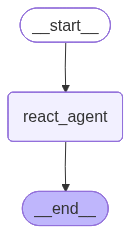

In [55]:
#Build langgraph

builder = StateGraph(Agentstate)

builder.add_node("react_agent", react_node)
builder.set_entry_point("react_agent")
builder.add_edge("react_agent", END)

graph=builder.compile()
graph

In [46]:
# Test wiki_tool
try:
    result = wiki_tool.invoke("Python programming")
    print("wiki_tool result:", result)
except Exception as e:
    print("wiki_tool ERROR:", e)

# Test retriever_tool
try:
    result = retriever_tool.invoke("Python programming")
    print("retriever_tool result:", result)
except Exception as e:
    print("retriever_tool ERROR:", e)

wiki_tool ERROR: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
Using Retriver Tool : 

retriever_tool result: try to add comments explaining very complex bits of logic.\nYou always follow the best practices for the requested languages in terms of describing the code written as a defined\npackage/project.\n\n\nPython toolbelt preferences:\n- pytest\n- dataclasses\n"
"arg name": "value"
        }
    }
}
Ensure the response can be parsed by Python json.loads
GPT-Engineer is another project to create a whole repository of code given a task specified in natural language. The GPT-Engineer is instructed to think over a list of smaller components to build and ask for user input to clarify questions as needed.
You always follow the best practices for the requested languages in terms of describing the code written as a defined
package/project.
Python toolbelt preferences:
14. Get Improved Code: "improve_code", args: "suggestions": "<list_of_suggest

In [78]:
# Run the react agent

from langchain_core.messages import HumanMessage

if __name__ == "__main__":
    user_query = "what is agent loop and how does wikipedia describe autonomous agent?"
    state = {"messages": [HumanMessage (content=user_query)]}
    result = graph.invoke(state)
    print ("\n Final Answer : \n", result["messages"][-1].content)

Using Retriver Tool : 


 Final Answer : 
 Based on Wikipedia and general AI concepts, here is an explanation of the **Agent Loop** and how Wikipedia describes an **Autonomous Agent**.

### 1. What is the Agent Loop?

The **Agent Loop** (often referred to as the **Perception-Action Loop** or **Sense-Think-Act Cycle**) is the fundamental operational cycle of an autonomous agent. It describes the continuous process by which an agent interacts with its environment to achieve its goals.

While Wikipedia does not have a dedicated page for "Agent Loop," it is a core concept in the definition of **Intelligent Agents**. The loop typically consists of three main stages:

1.  **Perception (Sense):** The agent gathers information about its current state and the environment through sensors or inputs (e.g., reading text, observing a screen, receiving data).
2.  **Cognition (Think/Plan):** The agent processes this information using its internal logic, memory, or AI model (like an LLM). It decides on